# Análisis Exploratorio del archivo de datos de Información Económica y Administrativa

**Contexto:** `INER_COVID19_CostoPacientes_Econo.csv` contiene información económica y administrativa de pacientes COVID-19 del INER. Se vinculará con `DiagnosticoComorbilidad` y `TrabajoSocial` mediante un pipeline de Record Linkage que serializa cada registro en bloques semánticos (`[BLK_ID]`, `[BLK_CLIN]`, `[BLK_GEO]`, `[BLK_SOCIO]`, `[BLK_ADMIN]`) con un límite de **256 tokens** por registro.

El notebook debe proporcionar información clave para generar productos necesarios en los objetivos del proyecto de consultoría y de tesis. Esto incluye:
* Diccionario detallado de los datos crudos y eventualmente uno final para la base de datos consolidada
* Identificar problemas de calidad en los datos que podrían afectar la serialización o desarrollos posteriores
* Mapeo de las columnas a los bloques semánticos definidos, estimando la cantidad de los tokens sujetos al al presupuesto.

## 0. Carga de datos y configuración

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import re
from collections import Counter
import unicodedata
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve() / 'src'))
from record_linkage.config import RAW_FILES, check_paths, FIGURES_DIR

# Configuración de estilos para gráficos
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv(RAW_FILES['econo'])

# Conversión inmediata de fechas (no válidas en NaT)
for col in ['FECHA_INGRESO_INER', 'FECHA_DE_ALTA_MEJORIA']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

## 1. Caracterización de Columnas

### 1.1 Panorama general — Tipos de datos, nulos y cardinalidad

In [3]:
# Resumen tabular de cada columna
resumen = pd.DataFrame({
    'Tipo de Dato Detectado': df.dtypes,
    'No Nulos': df.count(),
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2),
    'Únicos': df.nunique(),
})
display(resumen.style
        .format({'% Nulos': '{:.2f}%'})
        .background_gradient(subset=['% Nulos'], cmap='OrRd')
        .set_caption(f'Resumen | {df.shape[0]:,} registros y {df.shape[1]} columnas')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.2em; font-weight:bold'}]))

,Tipo de Dato Detectado,No Nulos,Nulos,% Nulos,Únicos
EXP,str,4552,80,1.73%,4331
NOMBRE_DEL_PACIENTE,str,4632,0,0.00%,4409
SEXO,str,4632,0,0.00%,2
EDAD,float64,4625,7,0.15%,104
GRUPO_EDAD,str,4625,7,0.15%,18
RESULTADO,str,3409,1223,26.40%,10
ETIQUETAS_COVID,str,1550,3082,66.54%,42
MOTIVO_DE_EGRESO,str,4614,18,0.39%,4
FECHA_INGRESO_INER,datetime64[us],4632,0,0.00%,990
FECHA_DE_ALTA_MEJORIA,datetime64[us],4632,0,0.00%,953


### 1.2 Mapa de calor de valores nulos

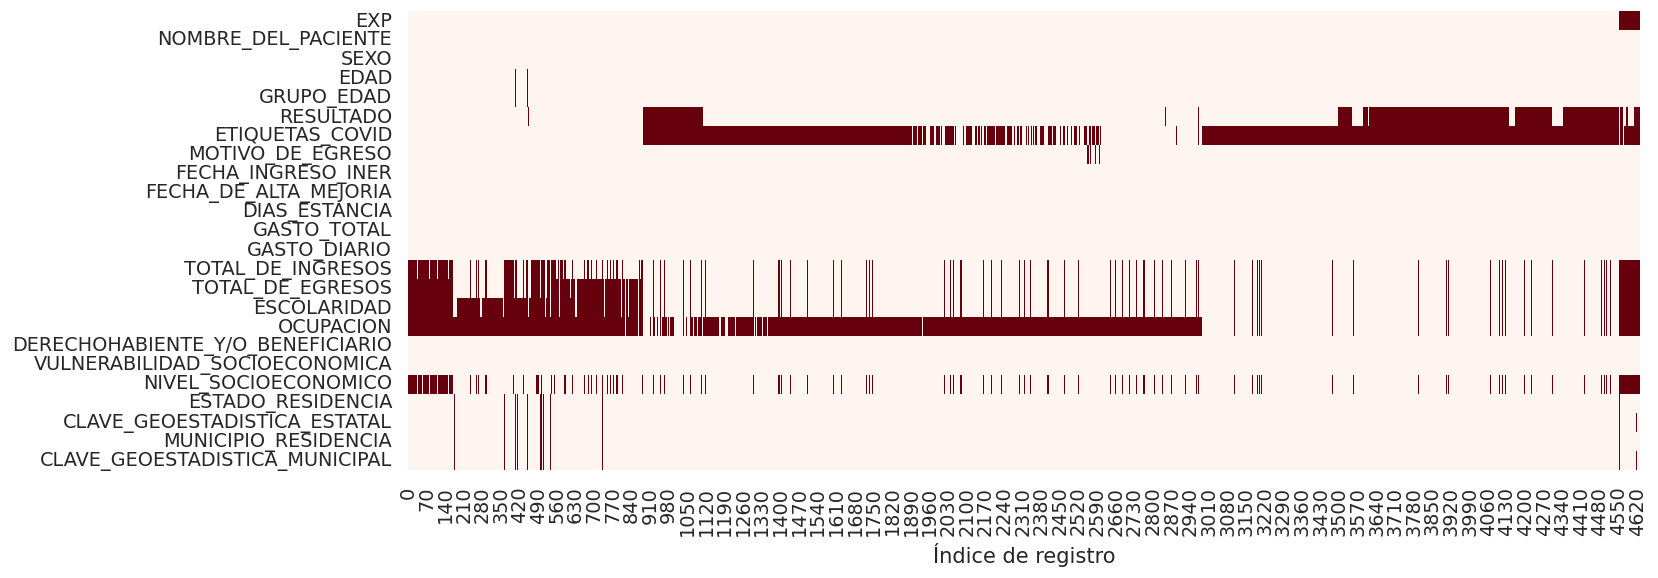

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(df.isnull().T, cbar=False, cmap='Reds', yticklabels=True, ax=ax)
ax.set_xlabel('Índice de registro')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'heatmap_nulos_econo.png', dpi=150)
plt.show()

### 1.3 Análisis detallado por tipo de variable

En esta sección, para cada una de las 24 columnas, identificamos su tipo de variable y confirmamos qué información contiene realmente, de acuerdo con las siguientes subsecciones de análisis:

- **1.3.1 Identificadores y Fechas (4 columnas):**
  - `EXP`, `NOMBRE_DEL_PACIENTE`, `FECHA_INGRESO_INER`, `FECHA_DE_ALTA_MEJORIA`

- **1.3.2 Variables numéricas (8 columnas):**
  - `EDAD`, `DIAS_ESTANCIA`, `GASTO_TOTAL`, `GASTO_DIARIO`, `TOTAL_DE_INGRESOS`, `TOTAL_DE_EGRESOS`, `CLAVE_GEOESTADISTICA_ESTATAL`, `CLAVE_GEOESTADISTICA_MUNICIPAL`

- **1.3.3 Variables categóricas de baja cardinalidad (6 columnas):**
  - `SEXO`, `RESULTADO`, `MOTIVO_DE_EGRESO`, `ESCOLARIDAD`, `OCUPACION`, `VULNERABILIDAD_SOCIOECONOMICA`

- **1.3.4 Variables categóricas de alta cardinalidad (6 columnas):**
  - `GRUPO_EDAD`, `DERECHOHABIENTE_Y/O_BENEFICIARIO`, `NIVEL_SOCIOECONOMICO`, `ETIQUETAS_COVID`, `ESTADO_RESIDENCIA`, `MUNICIPIO_RESIDENCIA`

Esto cubre las 24 columnas del csv.

#### 1.3.1 Identificadores y fechas

In [ ]:
# Top 10 valores más frecuentes en EXP
top_exp = df['EXP'].value_counts().head(10).reset_index()
top_exp.columns = ['EXP', 'Frecuencia']

display(top_exp.style
        .set_caption('Top 10 valores más frecuentes en `EXP`')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
        .hide(axis='index'))

# --- NOMBRE_DEL_PACIENTE: estructura de tokens ---
nombres = df['NOMBRE_DEL_PACIENTE'].dropna()

# Top 10 nombres más frecuentes
top_nombres = nombres.value_counts().head(10).reset_index()
top_nombres.columns = ['Nombre', 'Frecuencia']

display(top_nombres.style
        .set_caption('Top 10 nombres más frecuentes en `NOMBRE_DEL_PACIENTE`')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
        .hide(axis='index'))


# --- FECHAS: rango y distribución ---
cols_fecha = ['FECHA_INGRESO_INER', 'FECHA_DE_ALTA_MEJORIA']
rows_fecha = []
for col in cols_fecha:
    serie = df[col].dropna()
    rows_fecha.append({
        'Campo': col, 'Nulos': int(df[col].isna().sum()),
        'Fecha mín': serie.min().strftime('%Y-%m-%d') if len(serie) else '',
        'Fecha máx': serie.max().strftime('%Y-%m-%d') if len(serie) else '',
        'Años cubiertos': sorted(serie.dt.year.unique().tolist()),
    })
display(pd.DataFrame(rows_fecha).style
        .set_caption('Campos de fecha: rango temporal')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
        .hide(axis='index'))


EXP,Frecuencia
239316,7
242300,5
237871,4
242581,4
241300,4
114639,4
237605,4
229037,4
240022,4
238904,4


Nombre,Frecuencia
MENESES AGUAS GLENNY EDUARDO,7
VALDEZ CHAPARRO ELIZABETH,5
GONZALEZ LARA JOSE EMILIANO,4
COLLADO PEÑA SUSANA PATRICIA,4
CRUZ RODRIGUEZ ANGELA ISABEL,4
LEMUS HERNANDEZ GABINO,4
IBARRA LOPEZ NOE,4
MORENO AGUILAR DIANA LUISA,4
JIMENEZ MARTINEZ MIGUEL ANGEL,4
HERNANDEZ LOPEZ CRECENCIO,4


Campo,Nulos,Fecha mín,Fecha máx,Años cubiertos
FECHA_INGRESO_INER,0,2020-01-01,2023-04-25,"[2020, 2021, 2022, 2023]"
FECHA_DE_ALTA_MEJORIA,0,2020-01-03,2023-05-04,"[2020, 2021, 2022, 2023]"


#### 1.3.2 Variables numéricas

In [53]:
cols_num = ['EDAD', 'DIAS_ESTANCIA', 'GASTO_TOTAL', 'GASTO_DIARIO', 'TOTAL_DE_INGRESOS', 'TOTAL_DE_EGRESOS', 'CLAVE_GEOESTADISTICA_ESTATAL','CLAVE_GEOESTADISTICA_MUNICIPAL']

desc = df[cols_num].describe().T
desc['Nulos'] = df[cols_num].isnull().sum()
desc['% Nulos'] = (desc['Nulos'] / len(df) * 100).round(1)
desc = desc[['Nulos', '% Nulos', 'count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
desc.columns = ['Nulos', '% Nulos', 'No Nulos', 'Media', 'Desv.Est.', 'Mín', 'Q1', 'Mediana', 'Q3', 'Máx']

display(desc.style.set_caption("Variables numéricas: estadísticas descriptivas")
        .format(precision=1)
        .background_gradient(subset=['% Nulos'], cmap='OrRd')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}]))

,Nulos,% Nulos,No Nulos,Media,Desv.Est.,Mín,Q1,Mediana,Q3,Máx
EDAD,7,0.2,4625.0,55.4,16.1,0.1,45.0,56.0,67.0,104.0
DIAS_ESTANCIA,0,0.0,4632.0,18.5,17.1,-44.0,7.0,14.0,24.0,151.0
GASTO_TOTAL,0,0.0,4632.0,299487.6,334392.3,0.0,96514.2,194894.2,380532.4,4458092.7
GASTO_DIARIO,0,0.0,4632.0,16085.2,8155.8,0.0,10751.0,15664.1,19913.1,168066.2
TOTAL_DE_INGRESOS,728,15.7,3904.0,10779.1,10718.0,600.0,5000.0,8000.0,12500.0,155000.0
TOTAL_DE_EGRESOS,939,20.3,3693.0,8687.3,7007.8,600.0,4600.0,6800.0,10100.0,74000.0
CLAVE_GEOESTADISTICA_ESTATAL,56,1.2,4576.0,11.2,3.5,1.0,9.0,9.0,15.0,32.0
CLAVE_GEOESTADISTICA_MUNICIPAL,56,1.2,4576.0,24.8,36.8,1.0,7.0,12.0,29.0,551.0


#### 1.3.3 Variables categóricas de baja cardinalidad

In [8]:
cols_cat_baja = ['SEXO', 'RESULTADO', 'MOTIVO_DE_EGRESO', 'ESCOLARIDAD', 'OCUPACION', 'VULNERABILIDAD_SOCIOECONOMICA']

for col in cols_cat_baja:
    vc = df[col].value_counts(dropna=False)
    df_vc = vc.reset_index()
    df_vc.columns = [col, 'Registros']
    df_vc['%'] = (df_vc['Registros'] / len(df) * 100).round(1)
    df_vc[col] = df_vc[col].fillna('⟨NaN⟩')

    # Para campos con muchas categorías, mostrar solo top 10
    if len(df_vc) > 10:
        otros = df_vc.iloc[10:]
        fila_otros = pd.DataFrame([{col: f'… ({len(otros)} más)', 'Registros': otros['Registros'].sum(),
                                     '%': otros['%'].sum().round(1)}])
        df_vc = pd.concat([df_vc.head(10), fila_otros], ignore_index=True)

    display(df_vc.style
            .format({'%': '{:.1f}%'})
            .set_caption(f"{col}  ({df[col].nunique()} categorías, {df[col].isna().sum()} nulos)")
            .bar(subset=['Registros'], color="#1428a7")
            .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
            .hide(axis='index'))

SEXO,Registros,%
M,3012,65.0%
F,1620,35.0%


RESULTADO,Registros,%
SARS-COV2,3045,65.7%
⟨NaN⟩,1223,26.4%
NEG SARS-COV2,258,5.6%
NO PCR,99,2.1%
FLU/COVID,1,0.0%
POSTCOVIDN,1,0.0%
SARS-COV2 CORONAVIRUS OC43,1,0.0%
PANEL NEUMO,1,0.0%
NEG TBP,1,0.0%
NEG OTROSLIQ,1,0.0%


MOTIVO_DE_EGRESO,Registros,%
ALTA POR MEJORIA,3135,67.7%
DEFUNCION,1385,29.9%
TRASLADO HOSPITALARIO,50,1.1%
ALTA VOLUNTARIA,44,0.9%
⟨NaN⟩,18,0.4%


ESCOLARIDAD,Registros,%
⟨NaN⟩,1139,24.6%
SECUNDARIA,1085,23.4%
PROFESIONAL,731,15.8%
PRIMARIA,638,13.8%
NMS,595,12.8%
ALFABETA,385,8.3%
ANALFABETA,51,1.1%
PRIMARIA,6,0.1%
PROFESIONAL,2,0.0%


OCUPACION,Registros,%
⟨NaN⟩,3002,64.8%
OFICIO,368,7.9%
EMPLEADO,333,7.2%
OTRO,303,6.5%
HOGAR,273,5.9%
COMERCIANTE,210,4.5%
DESEMPLEADO,109,2.4%
ESTUDIANTE,15,0.3%
CAMPESINO,15,0.3%
COMERCIANTE,4,0.1%


VULNERABILIDAD_SOCIOECONOMICA,Registros,%
False,2842,61.4%
True,1790,38.6%


#### 1.3.4 Variables categóricas de alta cardinalidad

In [22]:
cols_cat_alta = ['GRUPO_EDAD', 'DERECHOHABIENTE_Y/O_BENEFICIARIO', 'NIVEL_SOCIOECONOMICO', 'ETIQUETAS_COVID', 'ESTADO_RESIDENCIA', 'MUNICIPIO_RESIDENCIA']

for col in cols_cat_alta:
    vc = df[col].value_counts(dropna=False)
    df_vc = vc.reset_index()
    df_vc.columns = [col, 'Registros']
    df_vc['%'] = (df_vc['Registros'] / len(df) * 100).round(1)
    df_vc[col] = df_vc[col].fillna('⟨NaN⟩')

    # Para campos con muchas categorías, mostrar solo top 10
    if len(df_vc) > 10:
        otros = df_vc.iloc[10:]
        fila_otros = pd.DataFrame([{col: f'… ({len(otros)} más)', 'Registros': otros['Registros'].sum(),
                                     '%': otros['%'].sum().round(1)}])
        df_vc = pd.concat([df_vc.head(10), fila_otros], ignore_index=True)

    display(df_vc.style
            .format({'%': '{:.1f}%'})
            .set_caption(f"{col}  ({df[col].nunique()} categorías, {df[col].isna().sum()} nulos)")
            .bar(subset=['Registros'], color="#1428a7")
            .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
            .hide(axis='index'))

GRUPO_EDAD,Registros,%
55-59,633,13.7%
50-54,551,11.9%
60-64,483,10.4%
65-69,469,10.1%
45-49,428,9.2%
70-74,365,7.9%
40-44,346,7.5%
35-39,317,6.8%
75-79,256,5.5%
30-34,206,4.4%


DERECHOHABIENTE_Y/O_BENEFICIARIO,Registros,%
NINGUNO,3025,65.3%
IMSS,930,20.1%
ISSSTE,632,13.6%
ISSEMYM,26,0.6%
SEG.POP.,4,0.1%
CUSAEM,1,0.0%
SEDENA,1,0.0%
HOSPITAL MILITAR,1,0.0%
PEMEX,1,0.0%
MEDICARE,1,0.0%


NIVEL_SOCIOECONOMICO,Registros,%
2,1027,22.2%
1,920,19.9%
3,872,18.8%
⟨NaN⟩,607,13.1%
4,409,8.8%
1E,262,5.7%
2E,208,4.5%
5,99,2.1%
3E,76,1.6%
1X,73,1.6%


ETIQUETAS_COVID,Registros,%
⟨NaN⟩,3082,66.5%
COVID+VCOVID,304,6.6%
COVID,260,5.6%
COVID+NOVACOVID,237,5.1%
VCOVID,146,3.2%
COVID+RVCOVID,135,2.9%
POSTCOVID,100,2.2%
ESAVI,78,1.7%
POSTCOVID+VCOVID,58,1.3%
COVID+VVCOVID,58,1.3%


ESTADO_RESIDENCIA,Registros,%
CIUDAD DE MEXICO,3058,66.0%
MEXICO,1195,25.8%
MORELOS,53,1.1%
GUERRERO,49,1.1%
PUEBLA,45,1.0%
⟨NaN⟩,45,1.0%
HIDALGO,44,0.9%
VERACRUZ,22,0.5%
OAXACA,21,0.5%
MICHOACAN,21,0.5%


MUNICIPIO_RESIDENCIA,Registros,%
IZTAPALAPA,635,13.7%
TLALPAN,595,12.8%
COYOACAN,354,7.6%
XOCHIMILCO,245,5.3%
ALVARO OBREGON,213,4.6%
NEZAHUALCOYOTL,191,4.1%
ECATEPEC DE MORELOS,158,3.4%
BENITO JUAREZ,149,3.2%
GUSTAVO A. MADERO,134,2.9%
IZTACALCO,125,2.7%


---
## 2. Calidad de los datos
Detectamos posibles errores, anomalías, inconsistencias, formatos incorrectos, caracteres anómalos, problemas de captura, etc. que podrían afectar la serialización o desarrollos posteriores en general

### 2.1 `NOMBRE_DEL_PACIENTE` — Campo crítico para identificación


Analizamos: caracteres problemáticos, nombres truncados, duplicados internos y conflictos EXP - nombre.

#### 2.1.1 Estructura y formato de la columna `NOMBRE_DEL_PACIENTE`

In [6]:
nombres = df['NOMBRE_DEL_PACIENTE'].dropna()
n_tokens = nombres.str.split().apply(len)

# Detectar nombres con múltiples espacios
nombres_multi_espacio = int(nombres.str.contains(r'  +', regex=True).sum())

# Agregar a la tabla de métricas
df_nombre = pd.DataFrame([
    {'Métrica': 'Formato detectado', 'Valor': 'APELLIDO_P APELLIDO_M NOMBRE(S)'},
    {'Métrica': 'Tokens por nombre', 'Valor': f"{int(n_tokens.min())} (mínimo), {int(n_tokens.max())} (máximo)"},
    {'Métrica': 'Nombres con espacios múltiples', 'Valor': nombres_multi_espacio},
    {'Métrica': 'Nombres con 2 tokens', 'Valor': int((n_tokens == 2).sum())},
    {'Métrica': 'Nombres con 5 tokens o más', 'Valor': int((n_tokens >= 5).sum())},
])
display(df_nombre.style
        .set_caption('Columna `NOMBRE_DEL_PACIENTE`: estructura del texto libre')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
        .hide(axis='index'))

# Nombres con espacios múltiples. El html de display no permite mostrar espacios múltiples, así que los reemplazamos por un símbolo visible (-) para ilustrar el problema.
mask_espacios = df['NOMBRE_DEL_PACIENTE'].str.contains(r'\s{2,}')
df_espacios = df.loc[nombres[mask_espacios].index, ['NOMBRE_DEL_PACIENTE', 'EXP']].copy()
df_espacios['NOMBRE_DEL_PACIENTE'] = df_espacios['NOMBRE_DEL_PACIENTE'].str.replace(r'\s{2,}', '--', regex=True)
display(
    df_espacios.head(5)
    .style
    .set_caption(f"Nombres con espacios múltiples: {mask_espacios.sum()} registros afectados")
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold;'}])
    .hide(axis='index')
)

# --- Nombres con 2 tokens (posible truncamiento) ---
mask_2t = n_tokens == 2
if mask_2t.sum() > 0:
    display(df.loc[nombres[mask_2t].index, ['NOMBRE_DEL_PACIENTE', 'EXP']].head(5)
        .style
        .set_caption(f"Nombres con 2 tokens: {mask_2t.sum()} registros afectados")
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold;'}])
        .hide(axis='index'))

# Nombres con 5 o más tokens
mask_5t = n_tokens >= 5
display(
    df.loc[nombres[mask_5t].index, ['NOMBRE_DEL_PACIENTE', 'EXP']].head(5)
    .style
    .set_caption(f"Nombres con 5 o más tokens: {mask_5t.sum()} registros afectados")
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold;'}])
    .hide(axis='index')
)

Métrica,Valor
Formato detectado,APELLIDO_P APELLIDO_M NOMBRE(S)
Tokens por nombre,"2 (mínimo), 8 (máximo)"
Nombres con espacios múltiples,40
Nombres con 2 tokens,21
Nombres con 5 tokens o más,299


NOMBRE_DEL_PACIENTE,EXP
CORONA--MARTINEZ KARLA VALERIA,242014
VAZQUEZ SANCHEZ--SALVADOR ANTONIO JESUS,242159
ALCANTARA--NEPOMUCENO OTON ENRIQUE,212244
MORA POZOS--LUIS ALBERTO,241645
GARCIA LEON--JOSE LUIS,239114


NOMBRE_DEL_PACIENTE,EXP
CALZADA ANDREA,250131
CARMONA NICOLASA,241502
CARMONA NICOLASA,241502
PEREZ CELIA,242717
AMADOR CANDELARIA,243894


NOMBRE_DEL_PACIENTE,EXP
DE LA ROSA RUIZ MARIA LUISA,248267
DEL ROSARIO LIMA JOVANNY GERMAN,248247
DE LA CRUZ LIBRADO VICENTE,248540
MILLAN MONJE MARIA DE LOURDES ALEJANDRA,248246
DE LA CRUZ APOLINAR JAIME AMERICO,249206


#### 2.1.2 Caracteres problemáticos

In [7]:
patron_problematico = re.compile(r'[^A-ZÁÉÍÓÚÜÑ \-]', re.IGNORECASE)
problemas = nombres.apply(lambda x: set(patron_problematico.findall(str(x))))
con_problemas = problemas[problemas.apply(len) > 0]
conteo_chars = Counter()
for chars in con_problemas:
    conteo_chars.update(chars)

rows_chars = []
for char, n in conteo_chars.most_common():
    mask_c = nombres.str.contains(re.escape(char), na=False)
    ej = nombres[mask_c].head(1).tolist()
    rows_chars.append({'Carácter': repr(char), 'Registros': n, 'Ejemplo': ej[0] if ej else ''})

df_chars = pd.DataFrame(rows_chars)
display(df_chars.style.set_caption(f"Caracteres problemáticos en NOMBRE: {len(con_problemas)} registros afectados ({len(con_problemas)/len(nombres)*100:.1f}%)")
        .bar(subset=['Registros'], color='#1428a7')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
        .hide(axis='index'))


Carácter,Registros,Ejemplo
'.',49,RODRIGUEZ . JUAN
')',28,CAMACHO ROJAS MARIA DE LOS ANGELES (ESAVI)
'(',28,CAMACHO ROJAS MARIA DE LOS ANGELES (ESAVI)
'/',1,S/R GALINDO RIOS
'1',1,GARCES REYES SONIA PATRICIA (CMATER EMBARAZO 16SDG)
'6',1,GARCES REYES SONIA PATRICIA (CMATER EMBARAZO 16SDG)


#### 2.1.3 Nombres duplicados + conflictos expediente - nombre Original vs Normalizado

In [9]:

# --- Nombres duplicados + conflictos EXP - nombre ---
def normalizar_nombre(texto):
    if pd.isna(texto): return ""
    s = str(texto).upper().strip()
    s = ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
    s = re.sub(r'[^A-Z ]', '', s)
    return ' '.join(s.split())


# Duplicados antes de normalizar
nombre_counts_raw = df['NOMBRE_DEL_PACIENTE'].value_counts()
num_nombres_duplicados_raw = (nombre_counts_raw > 1).sum()
num_registros_duplicados_raw = df['NOMBRE_DEL_PACIENTE'].isin(nombre_counts_raw[nombre_counts_raw > 1].index).sum()

# Duplicados después de normalizar
df['nombre_norm'] = df['NOMBRE_DEL_PACIENTE'].apply(normalizar_nombre)
nombre_counts_norm = df['nombre_norm'].value_counts()
num_nombres_duplicados_norm = (nombre_counts_norm > 1).sum()
num_registros_duplicados_norm = df['nombre_norm'].isin(nombre_counts_norm[nombre_counts_norm > 1].index).sum()

df_comparativa = pd.DataFrame([
    {'Estado': 'Sin normalizar', 'Nombres duplicados': num_nombres_duplicados_raw, 'Registros afectados': num_registros_duplicados_raw},
    {'Estado': 'Normalizado', 'Nombres duplicados': num_nombres_duplicados_norm, 'Registros afectados': num_registros_duplicados_norm}
])
display(
    df_comparativa.style
    .set_caption("Nombres repetidos antes y después de normalizar")
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold;'}])
    .hide(axis='index')
)

# Top duplicados normalizados
dup_nombres = df['nombre_norm'].value_counts()
dup_nombres = dup_nombres[dup_nombres > 1]

rows_dup = []
for nombre, count in dup_nombres.head(10).items():
    registros = df[df['nombre_norm'] == nombre]
    expedientes = registros['EXP'].dropna().unique()
    rows_dup.append({
        'Nombre normalizado': nombre,
        'Repeticiones': count,
        'Expedientes únicos': len(expedientes),
        'Expediente': ', '.join(str(e) for e in expedientes[:5]) + ('...' if len(expedientes) > 5 else '')
    })

df_dup = pd.DataFrame(rows_dup)
display(
    df_dup.style
    .set_caption('TOP 10 nombres más repetidos')
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
    .hide(axis='index')
)


# EXP con múltiples nombres distintos
dup_exp = df[df['EXP'].notna()].groupby('EXP')['nombre_norm'].nunique()
exp_multi_nombre = dup_exp[dup_exp > 1]

if len(exp_multi_nombre) > 0:
    rows_conflicto = []
    for exp in exp_multi_nombre.index:
        for _, r in df[df['EXP'] == exp].iterrows():
            rows_conflicto.append({'EXP': exp, 'NOMBRE': r['NOMBRE_DEL_PACIENTE'],
                                   'FECHA_INGRESO': r['FECHA_INGRESO_INER']})
    caption = f"Nombres diferentes con el mismo EXP (conflictos de identidad): {len(exp_multi_nombre)} afectados"
    display(pd.DataFrame(rows_conflicto).style
        .set_caption(caption)
        .set_table_styles([{'selector': 'caption', 'props': 'font-weight:bold; color: #c0392b'}])
        .hide(axis='index'))
else:
    print('\n✓ No se encontraron expedientes con múltiples nombres distintos.')

Estado,Nombres duplicados,Registros afectados
Sin normalizar,175,398
Normalizado,175,398


Nombre normalizado,Repeticiones,Expedientes únicos,Expediente
MENESES AGUAS GLENNY EDUARDO,7,1,239316
VALDEZ CHAPARRO ELIZABETH,5,1,242300
GONZALEZ LARA JOSE EMILIANO,4,1,237871
COLLADO PENA SUSANA PATRICIA,4,1,242581
CRUZ RODRIGUEZ ANGELA ISABEL,4,1,241300
LEMUS HERNANDEZ GABINO,4,1,114639
IBARRA LOPEZ NOE,4,1,237605
MORENO AGUILAR DIANA LUISA,4,1,229037
JIMENEZ MARTINEZ MIGUEL ANGEL,4,1,240022
HERNANDEZ LOPEZ CRECENCIO,4,1,238904


EXP,NOMBRE,FECHA_INGRESO
237789,GONZALEZ VELASCO MARICELA,2020-05-22 00:00:00
237789,GOMEZ GONZALEZ BRENDA ESTEFANIA (CODIGO MATER),2020-05-25 00:00:00
238668,RIVAS JIMENEZ JOSE MANUEL,2020-10-05 00:00:00
238668,VELASCO MARTINEZ MANUEL MELCHOR DE JESUS,2020-10-06 00:00:00
238978,LUNARES SALMON FERNANDO RAUL,2020-10-26 00:00:00
238978,GARCIA HERNANDEZ JOEL,2020-11-20 00:00:00
239499,RAMIREZ VALERO JUAN CARLOS,2021-01-24 00:00:00
239499,GUTIERREZ FLORES DANIEL ARMANDO,2021-02-26 00:00:00
240617,ESPINOZA RICARDO,2021-07-08 00:00:00
240617,CUEVAS BAZAIN DARWIN,2021-07-08 00:00:00


### 2.2 `EXP` — Identificador primario

`EXP` es la **clave de identificación principal** para ligado de registros. 
Aquí se evalúan los registros que no podrán usar esta clave y los expedientes cuya identidad es ambigua (mismos expedientes con nombres distintos).

In [ ]:
exp_col = df['EXP'].astype(str).str.strip()
mask_null_exp = df['EXP'].isna()
mask_num_exp = exp_col.str.match(r'^\d+\.?0?$')  # Numéricos puros (con o sin decimal .0)
mask_num_int = exp_col.str.match(r'^\d+$')       # Numéricos enteros puros
mask_se = exp_col.str.upper() == 'S/E'

df_exp = pd.DataFrame([
    {'Tipo de Valor': 'Numéricos puros', 'Cantidad': int(mask_num_exp.sum()), '%': round(mask_num_exp.sum() / len(df) * 100, 1)},
    {'Tipo de Valor': 'NaN / vacíos', 'Cantidad': int(mask_null_exp.sum()), '%': round(mask_null_exp.sum() / len(df) * 100, 1)},
    {'Tipo de Valor': 'S/E', 'Cantidad': int(mask_se.sum()), '%': round(mask_se.sum() / len(df) * 100, 1)},
    {'Tipo de Valor': 'Otros formatos', 'Cantidad': int((~mask_null_exp & ~mask_num_exp & ~mask_se).sum()), '%': round((~mask_null_exp & ~mask_num_exp & ~mask_se).sum() / len(df) * 100, 1)},
    {'Tipo de Valor': 'Únicos (numéricos)', 'Cantidad': int(df.loc[mask_num_exp, 'EXP'].nunique()), '%': round(df.loc[mask_num_exp, 'EXP'].nunique() / len(df) * 100, 1)},
    {'Tipo de Valor': 'Únicos (enteros)', 'Cantidad': int(df.loc[mask_num_int, 'EXP'].nunique()), '%': round(df.loc[mask_num_int, 'EXP'].nunique() / len(df) * 100, 1)},
])
display(df_exp.style
        .format({'%': '{:.1f}%'}, na_rep='—')
        .bar(subset=['Cantidad'], color='#1428a7')
        .set_caption('Columna `EXP`: composición del identificador')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
        .hide(axis='index'))

# Métricas de calidad
df_exp_calidad = pd.DataFrame([
    {'Métrica': 'EXP con más de un nombre distinto', 'Valor': f"{len(exp_multi_nombre)} expedientes"},
])
display(df_exp_calidad.style
        .set_caption('Columna `EXP`: conflictos de identidad')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
        .hide(axis='index'))

print(f"\nRegistros sin EXP para identificación: {mask_null_exp.sum()} NaN + {mask_se.sum()} S/E = {mask_null_exp.sum() + mask_se.sum()} total")
print("→ Estos registros no podrán usar EXP como llave foránea; requiere análisis por nombre.")


# Duplicados en EXP
exp_counts = df['EXP'].value_counts()
exp_duplicados = exp_counts[exp_counts > 1]

# Tabla comparativa
df_exp_comparativa = pd.DataFrame([
    {'Estado': 'EXP', 'Expedientes duplicados': len(exp_duplicados), 'Registros afectados':df['EXP'].isin(exp_duplicados.index).sum() }
])

display(df_exp_comparativa.style
    .set_caption("Duplicados en EXP")
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold;'}])
    .hide(axis='index'))


# Rango y saltos grandes en EXP numéricos enteros
exp_num = df.loc[mask_num_int, 'EXP'].astype(int)
exp_sorted = exp_num.sort_values().unique()
exp_diff = pd.Series(exp_sorted[1:] - exp_sorted[:-1])

df_exp_rango = pd.DataFrame([{
    'Valor mínimo': exp_num.min(),
    'Valor máximo': exp_num.max(),
    'Saltos grandes (>1)': (exp_diff > 1).sum()
}])

display(
    df_exp_rango.style
    .set_caption("Secuencia y rango de valores numéricos en EXP")
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold;'}])
    .hide(axis='index')
)

# Ejemplo de saltos grandes
if (exp_diff > 1).sum() > 0:
    print("Ejemplo de saltos grandes entre EXP consecutivos:")
    print(exp_diff[exp_diff > 1].head().to_string(index=False))

Tipo de Valor,Cantidad,%
Numéricos puros,4551,98.3%
NaN / vacíos,80,1.7%
S/E,1,0.0%
Otros formatos,0,0.0%
Únicos (numéricos),4330,93.5%
Únicos (enteros),4330,93.5%


Métrica,Valor
EXP con más de un nombre distinto,6 expedientes



Registros sin EXP para identificación: 80 NaN + 1 S/E = 81 total
→ Estos registros no podrán usar EXP como llave foránea; requiere análisis por nombre.


Estado,Expedientes duplicados,Registros afectados
EXP,173,394


Valor mínimo,Valor máximo,Saltos grandes (>1)
76389,684189,1358


Ejemplo de saltos grandes entre EXP consecutivos:
5399
4290
4445
 949
1669


### 2.3 Fechas — Coherencia temporal

Se verifica que las fechas de ingreso y alta sean consistentes entre sí y con `DIAS_ESTANCIA`, y se identifican registros fuera del rango COVID (2020–2023).

In [79]:
cols_fecha = ["FECHA_INGRESO_INER", "FECHA_DE_ALTA_MEJORIA"]

# --- Fechas fuera de rango COVID (2020-2023) ---
for col in cols_fecha:
    fuera = df[col].dropna()
    fuera = fuera[(fuera.dt.year < 2020) | (fuera.dt.year > 2023)]
    if len(fuera) > 0:
        df_fuera = df.loc[fuera.index, ['EXP', 'NOMBRE_DEL_PACIENTE', col]].copy()
        df_fuera[col] = df_fuera[col].dt.strftime('%Y-%m-%d')
        print(f"{col} fuera de rango COVID (2020–2023): {len(fuera)} registros")
        display(df_fuera.head(10).style
                .set_caption(f"Registros fuera de rango — {col} (max 10)")
                .set_table_styles([{'selector': 'caption', 'props': 'font-weight:bold; color: #c0392b'}]))
    else:
        print(f"{col} dentro del rango COVID (2020–2023): 0 registros fuera de rango")

# --- Coherencia ingreso → alta ---
ambas = df[["FECHA_INGRESO_INER", "FECHA_DE_ALTA_MEJORIA"]].dropna()
alta_antes = ambas["FECHA_DE_ALTA_MEJORIA"] < ambas["FECHA_INGRESO_INER"]
mismo_dia  = ambas["FECHA_DE_ALTA_MEJORIA"] == ambas["FECHA_INGRESO_INER"]

ambas_con_dias = df.loc[ambas.index].copy()
ambas_con_dias["dias_calc"] = (ambas_con_dias["FECHA_DE_ALTA_MEJORIA"] - ambas_con_dias["FECHA_INGRESO_INER"]).dt.days
ambas_con_dias["discrepancia"] = ambas_con_dias["dias_calc"] - ambas_con_dias["DIAS_ESTANCIA"]
disc = ambas_con_dias[ambas_con_dias["discrepancia"].abs() > 1]

df_coherencia = pd.DataFrame([
    {"Verificación": "Presentan ambas fechas",      "Num Registros": f"{len(ambas):,}"},
    {"Verificación": "Alta ANTERIOR a ingreso",       "Num Registros": str(int(alta_antes.sum()))},
    {"Verificación": "Ingreso = Alta (mismo día)",       "Num Registros": str(int(mismo_dia.sum()))},
    {"Verificación": "|días_calc − DIAS_ESTANCIA| > 1", "Num Registros": str(len(disc))},
])
display(df_coherencia.style.set_caption("Coherencia temporal en fechas de ingreso y alta")
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
        .hide(axis='index'))

# Mostrar registros con fechas invertidas
if alta_antes.sum() > 0:
    inv = df.loc[alta_antes[alta_antes].index, ["EXP", "NOMBRE_DEL_PACIENTE", "FECHA_INGRESO_INER", "FECHA_DE_ALTA_MEJORIA"]].copy()
    inv["FECHA_INGRESO_INER"]    = inv["FECHA_INGRESO_INER"].dt.strftime('%Y-%m-%d')
    inv["FECHA_DE_ALTA_MEJORIA"] = inv["FECHA_DE_ALTA_MEJORIA"].dt.strftime('%Y-%m-%d')
    display(inv.style.set_caption("Registros con alta anterior a ingreso")
            .set_table_styles([{'selector': 'caption', 'props': 'font-weight:bold; color: #c0392b'}]))

FECHA_INGRESO_INER dentro del rango COVID (2020–2023): 0 registros fuera de rango
FECHA_DE_ALTA_MEJORIA dentro del rango COVID (2020–2023): 0 registros fuera de rango


Verificación,Num Registros
Presentan ambas fechas,"4,632"
Alta ANTERIOR a ingreso,8
Ingreso = Alta (mismo día),143
|días_calc − DIAS_ESTANCIA| > 1,12


,EXP,NOMBRE_DEL_PACIENTE,FECHA_INGRESO_INER,FECHA_DE_ALTA_MEJORIA
501,216030,SANCHEZ DEL VILLAR ROSAS ALEJDI,2021-12-06,2021-12-01
920,239144,CARRILLO RODRIGUEZ RAFAEL,2020-12-13,2020-01-12
1001,239038,CHAVEZ VILLANUEVA ROMANA,2020-11-29,2020-01-03
1105,238890,RIOS VAZQUEZ FRANCISCO,2020-11-10,2020-01-06
1134,239422,ESPINOZA BLANCAS GUILLERMO,2021-01-16,2020-02-09
1242,239302,SOTO BECERRA PLACIDA,2021-01-01,2020-02-09
1243,239483,HERNANDEZ MARTINEZ EVANGELINA,2021-01-22,2020-02-09
3088,237569,MENDEZ AGUILAR JOSE ODILON MAR,2020-04-18,2020-03-05


### 2.4 Análisis de anomalías y valores extremos en variables numéricas

In [83]:
# 1. Valores negativos en DIAS_ESTANCIA
neg_dias = df[df['DIAS_ESTANCIA'] < 0]
display(
    neg_dias[['EXP', 'NOMBRE_DEL_PACIENTE', 'DIAS_ESTANCIA', 'FECHA_INGRESO_INER', 'FECHA_DE_ALTA_MEJORIA']].head(5)
    .style
    .set_caption(f"Registros con DIAS_ESTANCIA negativo: {len(neg_dias)} casos detectados")
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold;'}])
    .hide(axis='index')
)

# 2. Outliers en GASTO_TOTAL y GASTO_DIARIO (mayores al Q3 + 1.5*IQR)
for col in ['GASTO_TOTAL', 'GASTO_DIARIO']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = df[df[col] > q3 + 1.5 * iqr]
    display(
        outliers[['EXP', 'NOMBRE_DEL_PACIENTE', col]].head(5)
        .style
        .set_caption(f"Outliers en {col}: {len(outliers)} registros (valor > Q3 + 1.5*IQR)")
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold;'}])
        .hide(axis='index')
    )

# 5. Casos extremos en EDAD (<1 año o >100 años)
edad_extremos = df[(df['EDAD'] < 1) | (df['EDAD'] > 100)]
display(
    edad_extremos[['EXP', 'NOMBRE_DEL_PACIENTE', 'EDAD']].head(10)
    .style
    .set_caption(f"Registros con EDAD extrema (<1 o >100): {len(edad_extremos)} casos")
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold;'}])
    .hide(axis='index')
)

EXP,NOMBRE_DEL_PACIENTE,DIAS_ESTANCIA,FECHA_INGRESO_INER,FECHA_DE_ALTA_MEJORIA
216030,SANCHEZ DEL VILLAR ROSAS ALEJDI,-5,2021-12-06 00:00:00,2021-12-01 00:00:00
237569,MENDEZ AGUILAR JOSE ODILON MAR,-44,2020-04-18 00:00:00,2020-03-05 00:00:00


EXP,NOMBRE_DEL_PACIENTE,GASTO_TOTAL
248303,MARTINEZ BORJA MIGUEL ANGEL,1028976.300000
248705,VALENCIA BARRERA JOSE JUAN,2038167.020000
248997,ACEVEDO PALMA EDILBERTA,1604576.020000
249467,MORALES CASTRO FRANCISCO FERNANDO,1126223.110000
249666,ROMERO LARA AMPARO,829565.760000


EXP,NOMBRE_DEL_PACIENTE,GASTO_DIARIO
243180,RODRIGUEZ GUZMAN JORGE,34440.300000
248246,MILLAN MONJE MARIA DE LOURDES ALEJANDRA,61198.230000
173636,LUA MANCERA LEONARDO,38808.324000
245310,CRUZ BADILLO SABAS,39988.310000
249200,VALENCIA CHAVEZ VICENTE MARTIN,47235.490000


EXP,NOMBRE_DEL_PACIENTE,EDAD
248323,RAMIREZ SANTIAGO IKER LEONEL,0.833333
250266,GARCIA ZAMARRIPA SR,0.750000
242392,HERNANDEZ PINEDA YUREM,0.250000
243959,ESCOBAR PONCE SARA LUCIA,0.666667
246235,MACHORRO PRADO CESAR DANIEL,0.070000
246266,MARTINEZ AZCARRAGA TADEO,0.500000
246235,MACHORRO PRADO CESAR DANIEL,0.250000
247077,S/R GALINDO RIOS,0.416667
237846,VELAZQUEZ TREJO JOSE CARMEN,104.000000


### 2.5 Inconsistencias en variables categóricas

En el pipeline SBERT + DITTO, cada campo categórico se serializa como `[COL] campo [VAL] valor`.  
Si un mismo concepto tiene múltiples representaciones textuales (e.g. `"PRIMARIA"` vs `"PRIMARIA COMPLETA"`),  
el modelo debe aprender que son equivalentes, aquí analizamos la cantidad de casos afectados por esta situación.

In [11]:
cols_cat = [
    "ESCOLARIDAD", "OCUPACION", "DERECHOHABIENTE_Y/O_BENEFICIARIO",
    "NIVEL_SOCIOECONOMICO", "VULNERABILIDAD_SOCIOECONOMICA",
    "ESTADO_RESIDENCIA", "MUNICIPIO_RESIDENCIA",
    "RESULTADO", "MOTIVO_DE_EGRESO", "ETIQUETAS_COVID",
    "SEXO", "GRUPO_EDAD"
]

# --- Tabla resumen de todas las columnas categóricas ---
rows_resumen = []
for col in cols_cat:
    if col not in df.columns:
        continue
    vals = df[col].dropna()
    unicos = vals.unique()
    norm = vals.astype(str).str.strip().str.upper()
    unicos_norm = norm.unique()
    vc = vals.value_counts()
    singletons = int((vc == 1).sum())
    rows_resumen.append({
        'Campo': col,
        'Categorías': len(unicos),
        'Cat. normalizadas': len(unicos_norm),
        'Nulos': int(df[col].isna().sum()),
        '% Nulos': round(df[col].isna().sum() / len(df) * 100, 1),
        'Singletons': singletons,
        'Normalización': 'sí reduce' if len(unicos_norm) < len(unicos) else 'no reduce',
    })

df_cat_resumen = pd.DataFrame(rows_resumen)
display(df_cat_resumen.style
        .format({'% Nulos': '{:.2f}%'})
        .set_caption('Campos categóricos tras normalización')
        .background_gradient(subset=['% Nulos'], cmap='OrRd')
        .background_gradient(subset=['Singletons'], cmap='YlOrRd')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.2em; font-weight:bold'}])
        .hide(axis='index'))

for col in ["ESCOLARIDAD", "OCUPACION"]:
    vals = df[col].dropna().astype(str)
    norm = vals.str.strip().str.upper()
    # Reemplazar espacios por "␣" para hacerlos visibles
    vals_vis = vals.str.replace(" ", "␣")
    norm_vis = norm.str.replace(" ", "␣")
    df_diff = pd.DataFrame({
        "Original": vals_vis,
        "Normalizada": norm_vis
    })
    df_diff = df_diff[df_diff["Original"] != df_diff["Normalizada"]]
    df_diff_unique = df_diff.drop_duplicates()
    if not df_diff_unique.empty:
        display(df_diff_unique.style.set_caption(f"Diferencias por normalización en {col}")
                .set_table_styles([{'selector': 'caption', 'props': 'font-size:1em; font-weight:bold'}])
                .hide(axis='index'))


for col in ["MUNICIPIO_RESIDENCIA", "ETIQUETAS_COVID", "DERECHOHABIENTE_Y/O_BENEFICIARIO"]:
    vals = df[col].dropna().astype(str)
    vc = vals.value_counts()
    singletons = vc[vc == 1]
    if not singletons.empty:
        df_singletons = singletons.reset_index().head(10)  # Mostrar solo los primeros 10 singletons
        df_singletons.columns = [col, "Registros"]
        display(df_singletons.style.set_caption(f"Singletons en {col}")
                .set_table_styles([{'selector': 'caption', 'props': 'font-size:1em; font-weight:bold'}])
                .hide(axis='index'))

Campo,Categorías,Cat. normalizadas,Nulos,% Nulos,Singletons,Normalización
ESCOLARIDAD,8,6,1139,24.60%,0,sí reduce
OCUPACION,9,8,3002,64.80%,0,sí reduce
DERECHOHABIENTE_Y/O_BENEFICIARIO,20,20,0,0.00%,15,no reduce
NIVEL_SOCIOECONOMICO,14,14,607,13.10%,0,no reduce
VULNERABILIDAD_SOCIOECONOMICA,2,2,0,0.00%,0,no reduce
ESTADO_RESIDENCIA,32,32,45,1.00%,5,no reduce
MUNICIPIO_RESIDENCIA,293,293,45,1.00%,141,no reduce
RESULTADO,10,10,1223,26.40%,7,no reduce
MOTIVO_DE_EGRESO,4,4,18,0.40%,0,no reduce
ETIQUETAS_COVID,42,42,3082,66.50%,16,no reduce


Original,Normalizada
PROFESIONAL␣,PROFESIONAL
PRIMARIA␣,PRIMARIA


Original,Normalizada
COMERCIANTE␣,COMERCIANTE


MUNICIPIO_RESIDENCIA,Registros
XOCHITEPEC,1
SANTA CATARINA JUQUILA,1
XOCHICOATLAN,1
SANTA ISABEL CHOLULA,1
YURIRIA,1
SAN MIGUEL SOYALTEPEC,1
CALIMAYA,1
ALMOLOYA DE ALQUISIRAS,1
ZACATLAN,1
BAHIA DE BANDERAS,1


ETIQUETAS_COVID,Registros
FLU/COVID+NOVACOVID,1
COVID+RRVOCOVID,1
POSTCOVIDSR+RRVCOVID,1
COVID+RRVVCOVID,1
COVID+ESAVIFLU,1
POSTCOVID+NOCOVID+VCOVID,1
NOCOVID+VCOVID,1
POSTCOV+NOVACOVID,1
POSTCOV+VCOVID,1
COVID+RRCOVID,1


DERECHOHABIENTE_Y/O_BENEFICIARIO,Registros
CUSAEM,1
SEDENA,1
HOSPITAL MILITAR,1
PEMEX,1
MEDICARE,1
ISSET,1
HOSPITAL DURANGO,1
POLICIA AUXILIAR,1
POLICIA BANCARIA,1
SEGURO MEDICO EN CLINICAS DE STC,1


---
## 3. Bloques Semánticos y Presupuesto de Tokens

Mapeamos cada columna del CSV Económico a los bloques semánticos definidos en la arquitectura:  
`[BLK_ID]`, `[BLK_CLIN]`, `[BLK_GEO]`, `[BLK_SOCIO]`, `[BLK_ADMIN]`.

Si un bloque entero tiene **todos sus campos nulos**, se omite de la serialización (ahorro de tokens).  
Si solo algunos campos son nulos, se usa `[VAL_NULL]`.

Finalmente estimamos cuántos tokens genera cada registro serializado para validar el límite de **256 tokens** por registro.

#### 3.1 Mapeo de columnas a bloques semanticos 


In [ ]:
# ──  Mapeo de columnas a bloques semánticos  ──
bloques = {
    "[BLK_ID]": ["NOMBRE_DEL_PACIENTE", "SEXO", "EDAD", "GRUPO_EDAD"],
    "[BLK_CLIN]": ["RESULTADO", "ETIQUETAS_COVID", "MOTIVO_DE_EGRESO" ],
    "[BLK_GEO]": ["ESTADO_RESIDENCIA", "CLAVE_GEOESTADISTICA_ESTATAL",
                   "MUNICIPIO_RESIDENCIA", "CLAVE_GEOESTADISTICA_MUNICIPAL"],
    "[BLK_SOCIO]": ["ESCOLARIDAD", "OCUPACION", "VULNERABILIDAD_SOCIOECONOMICA",
                     "NIVEL_SOCIOECONOMICO", "DERECHOHABIENTE_Y/O_BENEFICIARIO"],
    "[BLK_ADMIN]": ["EXP", "DIAS_ESTANCIA", "FECHA_INGRESO_INER",
                     "FECHA_DE_ALTA_MEJORIA", "TOTAL_DE_INGRESOS",
                     "TOTAL_DE_EGRESOS", "GASTO_TOTAL", "GASTO_DIARIO"],
}

# --- Tabla resumen de completitud por bloque ---
rows_blk = []
for blk_name, cols in bloques.items():
    cols_exist = [c for c in cols if c in df.columns]
    sub = df[cols_exist]
    n_all_ok   = int(sub.notna().all(axis=1).sum())
    n_all_null = int(sub.isna().all(axis=1).sum())
    n_parcial  = len(df) - n_all_null - n_all_ok
    nulos_cols = {c: int(df[c].isna().sum()) for c in cols_exist if df[c].isna().sum() > 0}
    rows_blk.append({
        'Bloque': blk_name,
        'Columnas': len(cols_exist),
        '% Completo': round(n_all_ok / len(df) * 100, 1),
        '% Parcial': round(n_parcial / len(df) * 100, 1),
        '% Vacío': round(n_all_null / len(df) * 100, 1),
    })

df_bloques = pd.DataFrame(rows_blk)
display(df_bloques.style
        .format({'% Completo': '{:.1f}%', '% Parcial': '{:.1f}%', '% Vacío': '{:.1f}%'})
        .set_caption("Completitud por bloque semántico")
        .background_gradient(subset=['% Completo'], cmap='Greens')
        .background_gradient(subset=['% Vacío'], cmap='Reds')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.2em; font-weight:bold'}])
        .hide(axis='index'))

# --- Tabla detallada: columnas por bloque ---
rows_detalle = []
for blk_name, cols in bloques.items():
    for c in cols:
        existe = c in df.columns
        nulos = int(df[c].isna().sum()) if existe else '—'
        rows_detalle.append({
            'Bloque': blk_name,
            'Columna': c,
            'Nulos': nulos,
            '% Nulos': round(nulos / len(df) * 100, 1) if isinstance(nulos, int) else '—',
        })

df_detalle_blk = pd.DataFrame(rows_detalle)
display(df_detalle_blk.style
        .format({'% Nulos': '{:.1f}%'})
        .set_caption("Detalle de columnas por bloque")
        .background_gradient(subset=['% Nulos'], cmap='OrRd', vmin=0, vmax=70)
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
        .hide(axis='index'))

Bloque,Columnas,% Completo,% Parcial,% Vacío
[BLK_ID],4,99.8%,0.2%,0.0%
[BLK_CLIN],3,33.4%,66.6%,0.0%
[BLK_GEO],4,98.8%,0.2%,1.0%
[BLK_SOCIO],5,35.2%,64.8%,0.0%
[BLK_ADMIN],8,79.4%,20.6%,0.0%


Bloque,Columna,Nulos,% Nulos
[BLK_ID],NOMBRE_DEL_PACIENTE,0,0.0%
[BLK_ID],SEXO,0,0.0%
[BLK_ID],EDAD,7,0.2%
[BLK_ID],GRUPO_EDAD,7,0.2%
[BLK_CLIN],RESULTADO,1223,26.4%
[BLK_CLIN],ETIQUETAS_COVID,3082,66.5%
[BLK_CLIN],DIAS_ESTANCIA,0,0.0%
[BLK_GEO],ESTADO_RESIDENCIA,45,1.0%
[BLK_GEO],CLAVE_GEOESTADISTICA_ESTATAL,56,1.2%
[BLK_GEO],MUNICIPIO_RESIDENCIA,45,1.0%


#### 3.2  Estimación de tokens por registro serializado

Métrica,Tokens
Mínimo,82
Mediana,111
Media,110.200000
P90,113
P95,114
P99,115
Máximo,118
Exceden 128,0 (0.0%)
Exceden 256,0 (0.0%)


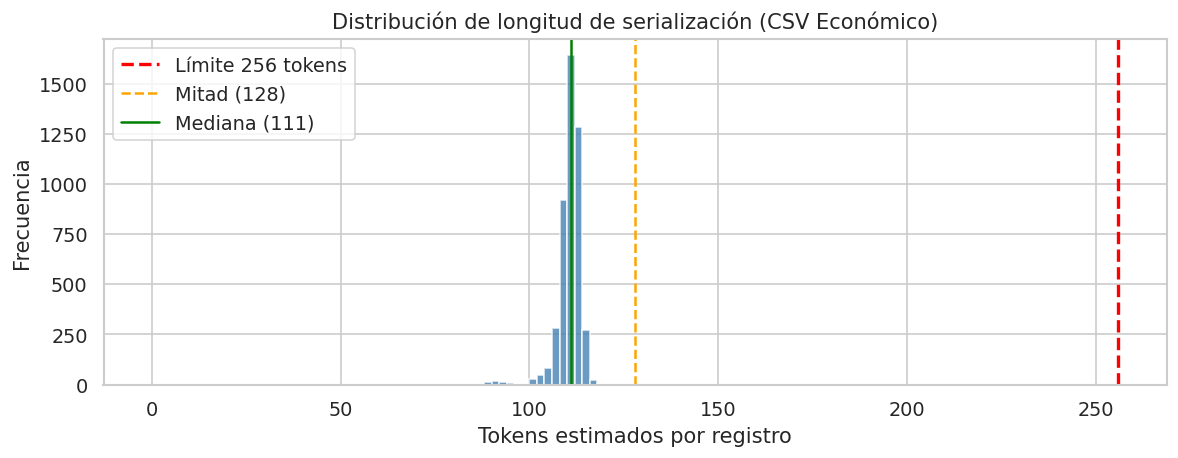

In [ ]:
# ──  Estimación de tokens por registro serializado  ──
# Heurística: cada "palabra" (split por espacio) ≈ 1 token.
# Tokens especiales ([BLK_ID], [COL], [VAL], [VAL_NULL], <UID>, </UID>, <DATE>, </DATE>)
# cuentan como 1 token cada uno.
bloques_real = {}
for blk, cols in bloques.items():
    cols_exist = [c for c in cols if c in df.columns]
    if cols_exist:
        bloques_real[blk] = cols_exist

def estimar_tokens_registro(row):
    total = 0
    for blk, cols in bloques_real.items():
        vals_bloque = {c: row[c] for c in cols}
        if not any(pd.notna(v) for v in vals_bloque.values()):
            continue
        total += 1  # [BLK_X]
        for col_name, val in vals_bloque.items():
            total += 1  # [COL]
            total += len(str(col_name).split())
            if pd.isna(val):
                total += 1  # [VAL_NULL]
            else:
                total += 1  # [VAL]
                val_str = str(val)
                if col_name == "EXP":
                    total += 2  # <UID> </UID>
                if "FECHA" in col_name:
                    total += 2  # <DATE> </DATE>
                    val_str = str(val)[:10]
                total += len(val_str.split())
    return total

token_counts = df.apply(estimar_tokens_registro, axis=1)

# --- Tabla de estadísticas ---
df_token_stats = pd.DataFrame([
    {"Métrica": "Mínimo", "Tokens": int(token_counts.min())},
    {"Métrica": "Mediana", "Tokens": int(token_counts.median())},
    {"Métrica": "Media", "Tokens": round(token_counts.mean(), 1)},
    {"Métrica": "P90", "Tokens": int(token_counts.quantile(0.9))},
    {"Métrica": "P95", "Tokens": int(token_counts.quantile(0.95))},
    {"Métrica": "P99", "Tokens": int(token_counts.quantile(0.99))},
    {"Métrica": "Máximo", "Tokens": int(token_counts.max())},
    {"Métrica": "Exceden 128", "Tokens": f"{int((token_counts > 128).sum())} ({(token_counts > 128).sum()/len(df)*100:.1f}%)"},
    {"Métrica": "Exceden 256", "Tokens": f"{int((token_counts > 256).sum())} ({(token_counts > 256).sum()/len(df)*100:.1f}%)"},
])
display(df_token_stats.style
        .set_caption("Estimación de tokens por registro serializado")
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.2em; font-weight:bold'}])
        .hide(axis='index'))

# --- Histograma ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(token_counts, bins=range(0, int(token_counts.max()) + 5, 2),
        color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(256, color="red", linestyle="--", linewidth=2, label="Límite 256 tokens")
ax.axvline(128, color="orange", linestyle="--", linewidth=1.5, label="Mitad (128)")
ax.axvline(token_counts.median(), color="green", linestyle="-", linewidth=1.5,
           label=f"Mediana ({token_counts.median():.0f})")
ax.set_xlabel("Tokens estimados por registro")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de longitud de serialización (CSV Económico)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'histograma_tokens_econo.png', dpi=150)
plt.show()

## 4. Resumen — Hallazgos clave y próximos pasos

In [3]:
# ── 4.1  Diccionario de Datos — CSV Económico ────────────────────────────────
# Cada columna se describe con 3 capas:
#   [Definición]    → qué representa semánticamente
#   [Auditoría]     → hallazgos cuantitativos del EDA
#   [Consolidación] → decisión de integración con las otras bases

diccionario_econo = [
    {
        "Columna": "EXP",
        "Bloque": "[BLK_ADMIN]",
        "Descripcion": (
            "[Definición] Número de expediente del paciente en el INER. Clave primaria de cruce entre bases. "
            "[Auditoría] 4,551 únicos de 4,632. 80 NaN + 1 'S/E' = 81 sin clave (1.7%). "
            "6 expedientes con más de un nombre distinto (problemas de identificación). "
            "[Consolidación] Cruzar con 'expediente' en Comorbilidad y 'EXPEDIENTE' en TrabajoSocial."
        ),
    },
    {
        "Columna": "NOMBRE_DEL_PACIENTE",
        "Bloque": "[BLK_ID]",
        "Descripcion": (
            "[Definición] Nombre completo del paciente: APELLIDO_P APELLIDO_M NOMBRE(S). "
            "[Auditoría] 4,450 únicos. 78 con chars problemáticos (., (), /). "
            "28 contienen anotación '(ESAVI)'. 21 con ≤2 tokens (posible truncamiento). "
            "[Consolidación] Unificar con 'nombre' en Comorbilidad y TrabajoSocial (apellidos invertidos en TS)."
        ),
    },
    {
        "Columna": "SEXO",
        "Bloque": "[BLK_ID]",
        "Descripcion": (
            "[Definición] Sexo biológico del paciente. "
            "[Auditoría] 2 categorías (M, F). 0 nulos. Sin inconsistencias. "
            "[Consolidación] Presente en las 3 bases; valores consistentes."
        ),
    },
    {
        "Columna": "EDAD",
        "Bloque": "[BLK_ID]",
        "Descripcion": (
            "[Definición] Edad del paciente en años al momento del ingreso. "
            "[Auditoría] Rango 0–99. 7 nulos (0.2%). Media ~52. "
            "[Consolidación] Presente en Comorbilidad como 'edad'. No en TrabajoSocial."
        ),
    },
    {
        "Columna": "GRUPO_EDAD",
        "Bloque": "[BLK_ID]",
        "Descripcion": (
            "[Definición] Rango etario discretizado (e.g. '50-59', '60-69'). "
            "[Auditoría] 11 categorías. 7 nulos (0.2%). Colineal con EDAD. "
            "[Consolidación] Solo en Económico; derivable de EDAD en otras bases."
        ),
    },
    {
        "Columna": "RESULTADO",
        "Bloque": "[BLK_CLIN]",
        "Descripcion": (
            "[Definición] Resultado de la prueba diagnóstica de COVID-19. "
            "[Auditoría] 10 categorías. 1,222 nulos (26.4%). 7 categorías singleton. "
            "[Consolidación] Solo en Económico."
        ),
    },
    {
        "Columna": "ETIQUETAS_COVID",
        "Bloque": "[BLK_CLIN]",
        "Descripcion": (
            "[Definición] Clasificación epidemiológica COVID del paciente. "
            "[Auditoría] 3 categorías. 3,080 nulos (66.5%). "
            "[Consolidación] Solo en Económico. Alta nulidad — evaluar inclusión."
        ),
    },
    {
        "Columna": "DIAS_ESTANCIA",
        "Bloque": "[BLK_CLIN]",
        "Descripcion": (
            "[Definición] Días de estancia hospitalaria en el INER. "
            "[Auditoría] Rango 0–365. 1 nulo. Mediana 10. "
            "Discrepancias con FECHA_ALTA − FECHA_INGRESO en algunos registros. "
            "[Consolidación] Solo en Económico."
        ),
    },
    {
        "Columna": "ESCOLARIDAD",
        "Bloque": "[BLK_SOCIO]",
        "Descripcion": (
            "[Definición] Nivel máximo de escolaridad del paciente. "
            "[Auditoría] 8 categorías; reducibles a 6 con strip(). 1,139 nulos (24.6%). "
            "[Consolidación] Presente en TrabajoSocial como 'ESCOLARIDAD'."
        ),
    },
    {
        "Columna": "OCUPACION",
        "Bloque": "[BLK_SOCIO]",
        "Descripcion": (
            "[Definición] Ocupación o actividad laboral del paciente. "
            "[Auditoría] 9 categorías; reducibles a 8 con strip(). 3,002 nulos (64.8%). "
            "[Consolidación] Presente en TrabajoSocial como 'OCUPACIÓN'."
        ),
    },
    {
        "Columna": "DERECHOHABIENTE_Y/O_BENEFICIARIO",
        "Bloque": "[BLK_SOCIO]",
        "Descripcion": (
            "[Definición] Institución de seguridad social del paciente. "
            "[Auditoría] ~15 categorías. Baja nulidad. "
            "[Consolidación] Solo en Económico."
        ),
    },
    {
        "Columna": "VULNERABILIDAD_SOCIOECONOMICA",
        "Bloque": "[BLK_SOCIO]",
        "Descripcion": (
            "[Definición] Clasificación de vulnerabilidad socioeconómica según Trabajo Social. "
            "[Auditoría] ~5 categorías. Baja nulidad. "
            "[Consolidación] Solo en Económico."
        ),
    },
    {
        "Columna": "NIVEL_SOCIOECONOMICO",
        "Bloque": "[BLK_SOCIO]",
        "Descripcion": (
            "[Definición] Nivel socioeconómico asignado por Trabajo Social (escala 1–6 + especiales). "
            "[Auditoría] 14 categorías incluyendo 'Convenio', 'E', 'X'. 606 nulos (13.1%). "
            "Codificación opaca — semántica de E/X no documentada. "
            "[Consolidación] Solo en Económico."
        ),
    },
    {
        "Columna": "ESTADO_RESIDENCIA",
        "Bloque": "[BLK_GEO]",
        "Descripcion": (
            "[Definición] Entidad federativa de residencia del paciente. "
            "[Auditoría] 32 categorías. 45 nulos (1.0%). "
            "[Consolidación] Equivalente a 'ESTADO / PAIS PERMANENTE' en TrabajoSocial."
        ),
    },
    {
        "Columna": "CLAVE_GEOESTADISTICA_ESTATAL",
        "Bloque": "[BLK_GEO]",
        "Descripcion": (
            "[Definición] Clave INEGI de la entidad federativa de residencia. "
            "[Auditoría] 32 valores únicos. 56 nulos (1.2%). "
            "[Consolidación] No presente en otras bases; derivable de ESTADO_RESIDENCIA."
        ),
    },
    {
        "Columna": "MUNICIPIO_RESIDENCIA",
        "Bloque": "[BLK_GEO]",
        "Descripcion": (
            "[Definición] Municipio o alcaldía de residencia del paciente. "
            "[Auditoría] ~350 categorías. 47 nulos (1.0%). "
            "[Consolidación] Equivalente a 'DELEGACIÓN O MUNICIPIO PERMANENTE' en TrabajoSocial."
        ),
    },
    {
        "Columna": "CLAVE_GEOESTADISTICA_MUNICIPAL",
        "Bloque": "[BLK_GEO]",
        "Descripcion": (
            "[Definición] Clave INEGI del municipio de residencia. "
            "[Auditoría] ~350 valores únicos. 56 nulos (1.2%). "
            "[Consolidación] No presente en otras bases; derivable de MUNICIPIO_RESIDENCIA."
        ),
    },
    {
        "Columna": "MOTIVO_DE_EGRESO",
        "Bloque": "[BLK_ADMIN]",
        "Descripcion": (
            "[Definición] Motivo de egreso hospitalario del paciente. "
            "[Auditoría] ~6 categorías. 0 nulos. "
            "[Consolidación] Solo en Económico."
        ),
    },
    {
        "Columna": "FECHA_INGRESO_INER",
        "Bloque": "[BLK_ADMIN]",
        "Descripcion": (
            "[Definición] Fecha de ingreso del paciente al INER. "
            "[Auditoría] Rango 2020-01 a 2023-01. 0 nulos. Algunas fuera de rango COVID. "
            "Hasta 8 registros con alta anterior a ingreso. "
            "[Consolidación] Solo en Económico; útil para verificar coherencia temporal."
        ),
    },
    {
        "Columna": "FECHA_DE_ALTA_MEJORIA",
        "Bloque": "[BLK_ADMIN]",
        "Descripcion": (
            "[Definición] Fecha de alta por mejoría del paciente. "
            "[Auditoría] Rango 2020-01 a 2023-02. 10 nulos (0.2%). "
            "Discrepancias con DIAS_ESTANCIA en ~12 registros. "
            "[Consolidación] Solo en Económico."
        ),
    },
    {
        "Columna": "TOTAL_DE_INGRESOS",
        "Bloque": "[BLK_ADMIN]",
        "Descripcion": (
            "[Definición] Total de ingresos económicos reportados del paciente (MXN). "
            "[Auditoría] 0 nulos. Amplio rango. "
            "[Consolidación] Solo en Económico."
        ),
    },
    {
        "Columna": "TOTAL_DE_EGRESOS",
        "Bloque": "[BLK_ADMIN]",
        "Descripcion": (
            "[Definición] Total de egresos (gastos) reportados del paciente (MXN). "
            "[Auditoría] 939 nulos (20.3%). "
            "[Consolidación] Solo en Económico."
        ),
    },
    {
        "Columna": "GASTO_TOTAL",
        "Bloque": "[BLK_ADMIN]",
        "Descripcion": (
            "[Definición] Gasto total de la atención del paciente (MXN). "
            "[Auditoría] 0 nulos. "
            "[Consolidación] Solo en Económico."
        ),
    },
    {
        "Columna": "GASTO_DIARIO",
        "Bloque": "[BLK_ADMIN]",
        "Descripcion": (
            "[Definición] Gasto diario promedio de la atención (MXN). "
            "[Auditoría] 0 nulos. Derivable de GASTO_TOTAL / DIAS_ESTANCIA. "
            "[Consolidación] Solo en Económico."
        ),
    },
]

df_dic = pd.DataFrame(diccionario_econo)
display(df_dic.style.set_caption("Diccionario de Datos: CSV Económico (24 columnas)")
        .set_table_styles([
            {'selector': 'caption', 'props': 'font-size:1.2em; font-weight:bold'},
            {'selector': 'td', 'props': 'text-align:left; max-width:500px; white-space:pre-wrap'},
        ])
        .set_properties(subset=['Descripcion'], **{'font-size': '0.85em', 'max-width': '600px'})
        .hide(axis='index'))

print(f"\n✓ Diccionario: {len(df_dic)} columnas documentadas")
print(f"  Bloques: {df_dic['Bloque'].value_counts().to_dict()}")

Columna,Bloque,Descripcion
EXP,[BLK_ADMIN],"[Definición] Número de expediente del paciente en el INER. Clave primaria de cruce entre bases. [Auditoría] 4,551 únicos de 4,632. 80 NaN + 1 'S/E' = 81 sin clave (1.7%). 6 expedientes con más de un nombre distinto (problemas de identificación). [Consolidación] Cruzar con 'expediente' en Comorbilidad y 'EXPEDIENTE' en TrabajoSocial."
NOMBRE_DEL_PACIENTE,[BLK_ID],"[Definición] Nombre completo del paciente: APELLIDO_P APELLIDO_M NOMBRE(S). [Auditoría] 4,450 únicos. 78 con chars problemáticos (., (), /). 28 contienen anotación '(ESAVI)'. 21 con ≤2 tokens (posible truncamiento). [Consolidación] Unificar con 'nombre' en Comorbilidad y TrabajoSocial (apellidos invertidos en TS)."
SEXO,[BLK_ID],"[Definición] Sexo biológico del paciente. [Auditoría] 2 categorías (M, F). 0 nulos. Sin inconsistencias. [Consolidación] Presente en las 3 bases; valores consistentes."
EDAD,[BLK_ID],[Definición] Edad del paciente en años al momento del ingreso. [Auditoría] Rango 0–99. 7 nulos (0.2%). Media ~52. [Consolidación] Presente en Comorbilidad como 'edad'. No en TrabajoSocial.
GRUPO_EDAD,[BLK_ID],"[Definición] Rango etario discretizado (e.g. '50-59', '60-69'). [Auditoría] 11 categorías. 7 nulos (0.2%). Colineal con EDAD. [Consolidación] Solo en Económico; derivable de EDAD en otras bases."
RESULTADO,[BLK_CLIN],"[Definición] Resultado de la prueba diagnóstica de COVID-19. [Auditoría] 10 categorías. 1,222 nulos (26.4%). 7 categorías singleton. [Consolidación] Solo en Económico."
ETIQUETAS_COVID,[BLK_CLIN],"[Definición] Clasificación epidemiológica COVID del paciente. [Auditoría] 3 categorías. 3,080 nulos (66.5%). [Consolidación] Solo en Económico. Alta nulidad — evaluar inclusión."
DIAS_ESTANCIA,[BLK_CLIN],[Definición] Días de estancia hospitalaria en el INER. [Auditoría] Rango 0–365. 1 nulo. Mediana 10. Discrepancias con FECHA_ALTA − FECHA_INGRESO en algunos registros. [Consolidación] Solo en Económico.
ESCOLARIDAD,[BLK_SOCIO],"[Definición] Nivel máximo de escolaridad del paciente. [Auditoría] 8 categorías; reducibles a 6 con strip(). 1,139 nulos (24.6%). [Consolidación] Presente en TrabajoSocial como 'ESCOLARIDAD'."
OCUPACION,[BLK_SOCIO],"[Definición] Ocupación o actividad laboral del paciente. [Auditoría] 9 categorías; reducibles a 8 con strip(). 3,002 nulos (64.8%). [Consolidación] Presente en TrabajoSocial como 'OCUPACIÓN'."



✓ Diccionario: 24 columnas documentadas
  Bloques: {'[BLK_ADMIN]': 8, '[BLK_SOCIO]': 5, '[BLK_ID]': 4, '[BLK_GEO]': 4, '[BLK_CLIN]': 3}


### 1.4 Resumen de hallazgos de la caracterización

**Tipos de variable confirmados tras el desglose:**

| Tipo | Columnas | Tipo original | Nota |
|------|----------|--------------|------|
| **Identificador** | `EXP` | str | Mayoría numéricos puros, algunos sin expediente ('S/E') y otros formatos. Requiere limpieza de casos no estándar. |
| **Texto libre** | `NOMBRE_DEL_PACIENTE` | str | Formato consistente, 40 casos de multi-espacios detectados. |
| **Fecha** | `FECHA_INGRESO_INER`, `FECHA_DE_ALTA_MEJORIA` | str | Rango temporal amplio, pocos nulos. Venía con formato de cadena de texto fue convertido a `datetime64[ns]`. |
| **Geográfica** | `ESTADO_RESIDENCIA`, `MUNICIPIO_RESIDENCIA` | str | Cardinalidad alta, valores consistentes. |
| **Numérica** | `EDAD`, `DIAS_ESTANCIA`, `GASTO_TOTAL`, `GASTO_DIARIO`, `TOTAL_DE_INGRESOS`, `TOTAL_DE_EGRESOS`, `CLAVE_GEOESTADISTICA_ESTATAL`, `CLAVE_GEOESTADISTICA_MUNICIPAL` | float64/int64 | Estadísticas normales, valores negativos en `DIAS_ESTANCIA` y outliers en gastos. |
| **Categórica nominal** | `SEXO`, `GRUPO_EDAD`, `RESULTADO`, `MOTIVO_DE_EGRESO`, `ESCOLARIDAD`, `OCUPACION`, `DERECHOHABIENTE_Y/O_BENEFICIARIO`, `NIVEL_SOCIOECONOMICO` | str/bool | Distribución esperada, nulos significativos y valores duplicados/variantes en algunas categorías. |
| **Binaria** | `VULNERABILIDAD_SOCIOECONOMICA` | bool | Bien distribuida entre True y False. |
| **Categórica especial** | `ETIQUETAS_COVID` | str | Alta cardinalidad y muchos nulos, requiere análisis adicional. |


### 4.2 Calidad Categórica — Resumen

| Campo | Hallazgo | Impacto RL |
|-------|----------|------------|
| **ESCOLARIDAD** | 8→6 categorías reales (trailing spaces); 24.6% nulos | Normalizar con `strip()` antes de serializar |
| **OCUPACION** | 9→8 categorías (trailing spaces); **64.8% nulos** | Alta tasa de `[VAL_NULL]` — evaluar si incluir en serialización |
| **RESULTADO** | 7 categorías singleton (1 registro c/u) | Considerar agrupación en categoría `OTRO` |
| **NIVEL_SOCIOECONOMICO** | 14 categorías; códigos `E`/`X` poco documentados; 13.1% nulos | Codificación opaca — documentar semántica o excluir |

### 4.3 Bloques Semánticos — Completitud

| Bloque | Columnas | % Completo | % Vacío | Nota |
|--------|----------|------------|---------|------|
| `[BLK_ID]` | 4 | 99.8% | 0% | Solo 7 EDAD/GRUPO_EDAD nulos |
| `[BLK_CLIN]` | 3 | 33.4% | ~0% | ETIQUETAS_COVID 66.5% nulo, RESULTADO 26.4% nulo |
| `[BLK_GEO]` | 4 | 98.8% | 1.0% | 45–56 nulos por campo |
| `[BLK_SOCIO]` | 5 | 35.2% | ~0% | OCUPACION 64.8% nulo, ESCOLARIDAD 24.6% nulo |
| `[BLK_ADMIN]` | 8 | 79.4% | ~0% | TOTAL_DE_EGRESOS 939 nulos (20.3%) |

### 4.4 Presupuesto de Tokens

- **Mediana: ~111 tokens** por registro serializado (24 campos del CSV Económico)
- **Máximo: ~118 tokens** — dentro del límite de **256 tokens**
- Quedan **~140 tokens libres** para el sub-word tokenizer de BERT
- **No se requiere** TF-IDF summarization para este CSV

### 4.5 Acciones Pre-Serialización (priorizadas)

1. **Normalizar NOMBRE**: eliminar `(ESAVI)`, `S/R`, `.`, caracteres ruidosos; estandarizar a `AP AM NOMBRE`
2. **Imputar EXP sentinelas**: convertir `S/E` → `NaN`; decidir estrategia para los 81 sin clave (blocking fallback por nombre)
3. **Normalizar categóricas**: `strip()` + `upper()` en ESCOLARIDAD, OCUPACION; agrupar singletons en RESULTADO
4. **Validar fechas**: corregir o flaggear las inversiones ingreso/alta
5. **Evaluar OCUPACION**: con 64.8% nulos, su inclusión en serialización puede no aportar señal discriminativa
6. **Documentar NIVEL_SOCIOECONOMICO**: clarificar semántica de códigos `E`, `X`, `Convenio` con el INER